# Data Ingestion

Every model in this repository starts from the same object: a `DataFrame` of closing prices, one column per ticker, indexed by date. `DataIngestion` is the only thing that talks to yfinance, and it is the only place a network call happens.

This notebook fetches a universe, checks it is what it claims to be, and turns it into the daily returns the models consume.

## Setup

`DataIngestion` takes optional `start_date` and `end_date` arguments; when omitted, it falls back to the values in `portfolio.config`.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from portfolio.data import DataIngestion, compute_returns

BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
INK, MUTED, GRID = "#1f2933", "#6b7785", "#e3e6ea"

sns.set_theme(style="whitegrid")

ingestion = DataIngestion()
f"window: {ingestion.start_date} → {ingestion.end_date}"

'window: 2022-12-01 → 2026-04-30'

## Fetching prices

Each `get_*_prices` method returns a DataFrame indexed by date with one column per ticker. Tickers are sorted alphabetically and rows containing NaN values are dropped.

In [13]:
stock_prices = ingestion.get_asset_class_prices("stocks")
stock_prices.tail()

,AAL,AAPL,ADBE,AMD,AMZN,AVGO,BA,BAC,CAT,CCL,...,SNAP,SOFI,T,TGT,TSLA,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-23,11.78,273.429993,238.979996,305.329987,255.080002,419.940002,234.149994,52.470001,835.239990,26.650000,...,5.57,18.320000,26.610001,130.169998,373.720001,308.880005,47.220001,80.510002,132.029999,150.529999
2026-04-24,12.10,271.059998,245.440002,347.809998,263.989990,422.760010,232.440002,52.049999,830.789978,27.170000,...,5.65,18.440001,26.200001,129.259995,376.299988,309.420013,46.380001,79.419998,129.919998,148.910004
2026-04-27,11.68,267.609985,239.309998,334.630005,261.119995,418.200012,231.330002,52.630001,828.789978,26.770000,...,6.06,18.760000,25.520000,129.720001,378.670013,309.649994,47.099998,80.559998,127.589996,148.190002
2026-04-28,11.64,270.709991,243.199997,323.209991,259.700012,399.829987,230.720001,52.660000,817.869995,26.299999,...,5.95,18.360001,26.059999,127.139999,376.019989,309.299988,47.240002,81.500000,127.589996,150.559998
2026-04-29,11.31,270.170013,243.570007,337.109985,263.040009,405.450012,224.110001,52.880001,810.049988,25.580000,...,5.98,15.525000,25.750000,127.870003,372.799988,334.859985,46.610001,81.510002,128.009995,154.669998


## EDA — shape, missingness, summary stats

Before modelling anything, it pays to confirm the data is what you expect. The four checks below catch the vast majority of ingestion-time problems (missing dates, dtype mismatches, constant columns, suspicious outliers).

In [14]:
print(f"shape:           {stock_prices.shape}")
print(f"date range:      {stock_prices.index.min().date()} → {stock_prices.index.max().date()}")
print(f"missing values:  {int(stock_prices.isna().sum().sum())}")
print(f"unique dtypes:   {stock_prices.dtypes.unique().tolist()}")

shape:           (854, 52)
date range:      2022-12-01 → 2026-04-29
missing values:  0
unique dtypes:   [dtype('float64')]


In [15]:
stock_prices.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
AAL,854.0,13.456089,2.130623,9.070000,11.597500,13.430000,14.867500,18.799999
AAPL,854.0,207.811756,37.713557,125.019997,178.625000,203.310005,235.044998,286.190002
ADBE,854.0,435.352540,101.673169,225.350006,350.950005,435.879990,521.177505,634.760010
AMD,854.0,144.587400,49.080518,62.330002,107.605000,138.714996,170.869995,347.809998
AMZN,854.0,177.282729,46.257687,81.820000,137.715000,185.004997,217.492500,263.989990
AVGO,854.0,182.174831,102.255301,51.849998,88.891750,162.209999,263.097488,422.760010
BA,854.0,198.717026,25.805329,136.589996,179.564995,201.705002,215.985001,264.269989
BAC,854.0,39.904286,8.536533,25.170000,32.750000,39.615000,46.840000,57.250000
CAT,854.0,372.740526,141.847432,205.750000,270.347511,342.229996,401.392494,835.239990
CCL,854.0,19.730375,6.863268,7.670000,14.830000,18.035001,25.790001,33.990002


## Visualizing price levels

Plotting raw price levels shows the rough scale and trend of each asset, but levels are not directly comparable across tickers (a stock at \$5 and one at \$500 say nothing about relative performance). Normalizing every series to start at 1 makes the comparison fair.

findfont: Failed to find font weight semibold, now using 700.


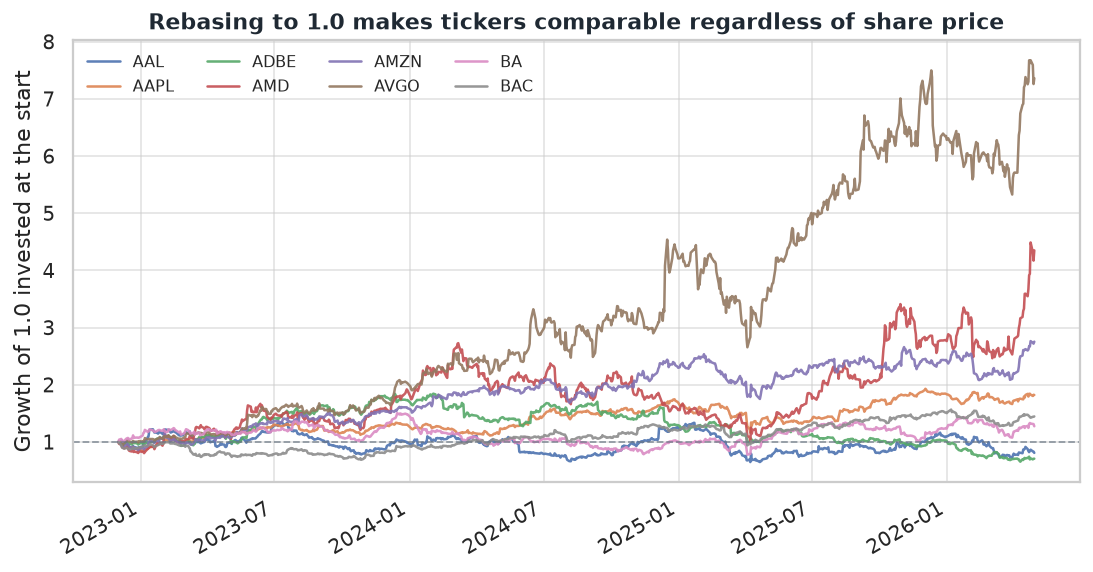

In [16]:
normalised = stock_prices / stock_prices.iloc[0]

fig, ax = plt.subplots(figsize=(10, 5))
normalised.iloc[:, :8].plot(ax=ax, alpha=0.9, linewidth=1.4)
ax.axhline(1.0, color=MUTED, linestyle="--", linewidth=1, alpha=0.7)
ax.set_ylabel("Growth of 1.0 invested at the start")
ax.set_xlabel("")
ax.set_title("Rebasing to 1.0 makes tickers comparable regardless of share price")
ax.legend(ncol=4, fontsize=9, loc="upper left")
plt.show()

## 5. Computing returns

`compute_returns` applies `pct_change` and drops the leading NaN row. It is a module-level function, so you can pass it any price DataFrame — including one you loaded from disk.

In [17]:
stock_returns = compute_returns(stock_prices)
stock_returns.tail()

,AAL,AAPL,ADBE,AMD,AMZN,AVGO,BA,BAC,CAT,CCL,...,SNAP,SOFI,T,TGT,TSLA,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-23,0.024348,0.000952,-0.066266,0.006162,-0.001096,-0.006412,0.012409,-0.012236,0.032601,-0.010765,...,-0.046233,-0.038825,0.024249,-0.003293,-0.035586,-0.007742,0.026968,-0.000869,0.015772,0.006890
2026-04-24,0.027165,-0.008668,0.027032,0.139128,0.034930,0.006715,-0.007303,-0.008005,-0.005328,0.019512,...,0.014363,0.006550,-0.015408,-0.006991,0.006904,0.001748,-0.017789,-0.013539,-0.015981,-0.010762
2026-04-27,-0.034711,-0.012728,-0.024976,-0.037894,-0.010872,-0.010786,-0.004775,0.011143,-0.002407,-0.014722,...,0.072566,0.017354,-0.025954,0.003559,0.006298,0.000743,0.015524,0.014354,-0.017934,-0.004835
2026-04-28,-0.003425,0.011584,0.016255,-0.034127,-0.005438,-0.043926,-0.002637,0.000570,-0.013176,-0.017557,...,-0.018152,-0.021322,0.021160,-0.019889,-0.006998,-0.001130,0.002972,0.011668,0.000000,0.015993
2026-04-29,-0.028351,-0.001995,0.001521,0.043006,0.012861,0.014056,-0.028649,0.004178,-0.009561,-0.027376,...,0.005042,-0.154412,-0.011896,0.005742,-0.008563,0.082638,-0.013336,0.000123,0.003292,0.027298


### Distribution of daily returns

Daily returns are the input to every model in this repository. A quick histogram shows the central peak around zero and the fat tails that motivate VaR / CVaR.

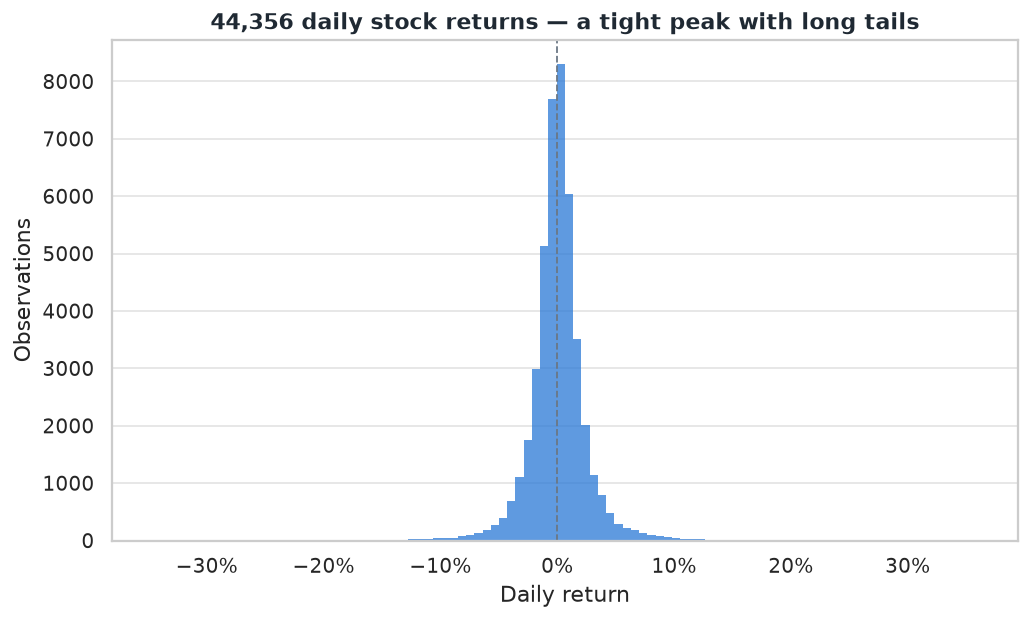

In [18]:
daily = stock_returns.stack()

fig, ax = plt.subplots()
sns.histplot(daily, bins=100, ax=ax, color=BLUE, edgecolor="none")
ax.axvline(0, color=MUTED, linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Daily return")
ax.set_ylabel("Observations")
ax.set_title(f"{len(daily):,} daily stock returns — a tight peak with long tails")
plt.show()

### Correlation structure

A correlation heatmap surfaces clusters of co-moving assets. These clusters matter for portfolio construction: the diversification benefit comes from combining assets with low (or negative) correlations.

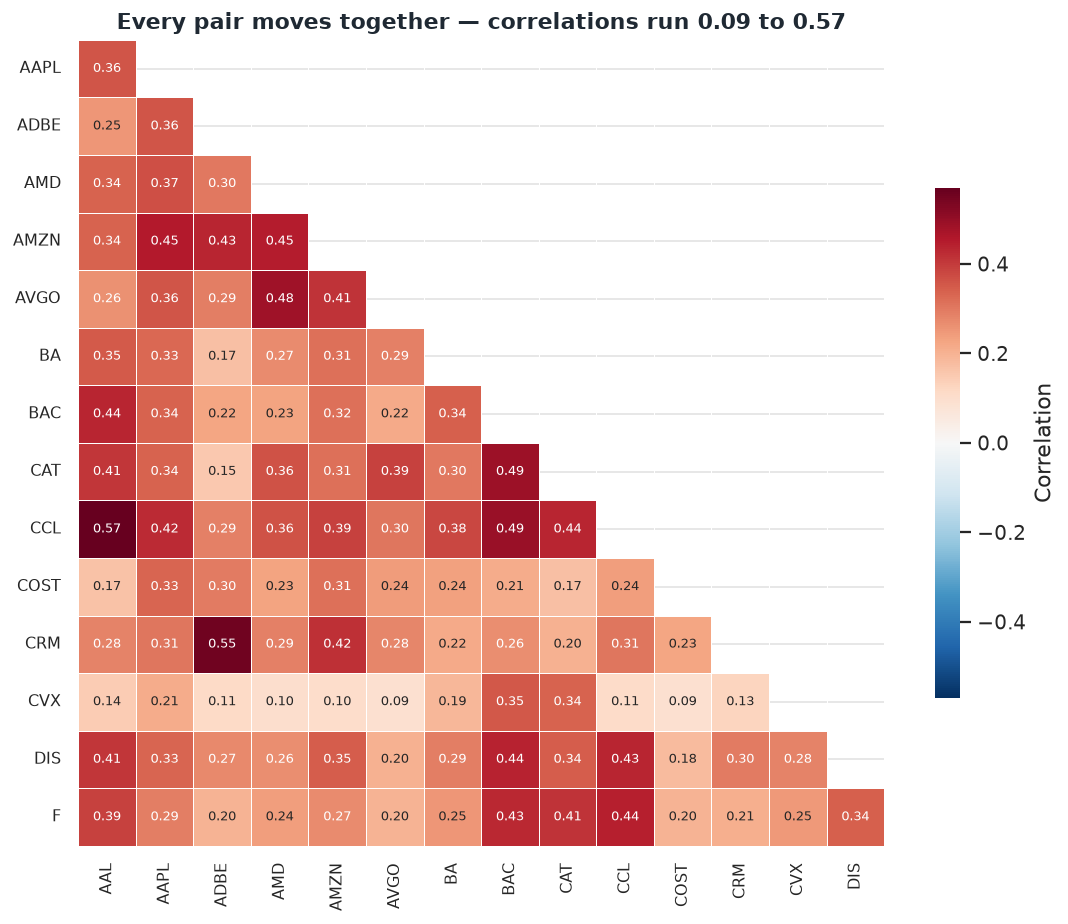

In [19]:
correlations = stock_returns.iloc[:, :15].corr()

# Trimming the first row and last column drops the empty corner the mask would leave.
lower = correlations.iloc[1:, :-1]
mask = np.triu(np.ones_like(lower, dtype=bool), k=1)
pairs = lower.to_numpy()[~mask]
limit = np.abs(pairs).max()

fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(
    lower,
    mask=mask,
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.6, "label": "Correlation"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"Every pair moves together — correlations run {pairs.min():.2f} to {pairs.max():.2f}")
ax.tick_params(axis="x", labelrotation=90, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.show()

## Other asset classes

`get_asset_class_prices` accepts any preset name registered in `portfolio.config.ASSET_CLASSES` (`"stocks"`, `"etfs"`, `"bonds"`, `"crypto"`) and raises a `ValueError` listing the available names for anything else. `get_market_prices` fetches the market proxy alone, and `get_all_prices` returns the entire universe in one DataFrame.

In [20]:
ingestion.get_asset_class_prices("bonds").tail()

,^FVX,^IRX,^TNX,^TYX
Date,,,,
2026-04-23,3.952,3.595,4.323,4.918
2026-04-24,3.920,3.593,4.310,4.916
2026-04-27,3.947,3.590,4.336,4.942
2026-04-28,3.983,3.590,4.354,4.944
2026-04-29,4.065,3.590,4.418,4.987


In [21]:
ingestion.get_asset_class_prices("crypto").tail()

,ADA-USD,BNB-USD,BTC-USD,DOGE-USD,ETH-USD,LINK-USD,SOL-USD,TRX-USD,USDC-USD,USDT-USD,XRP-USD,ZEC-USD
Date,,,,,,,,,,,,
2026-04-25,0.250270,628.657288,77612.015625,0.098048,2318.829102,9.346175,86.151176,0.324008,0.999733,1.000167,1.424219,359.027161
2026-04-26,0.252328,636.111450,78657.539062,0.099289,2369.729004,9.494079,86.970383,0.323531,0.999955,1.000292,1.431575,355.121796
2026-04-27,0.248151,626.964233,77366.625000,0.098978,2303.063965,9.320954,84.817787,0.325239,0.999820,0.999889,1.400906,355.729797
2026-04-28,0.246805,624.311035,76350.671875,0.099379,2289.419678,9.239625,84.038979,0.323010,0.999953,0.999902,1.380665,335.626892
2026-04-29,0.244517,617.329773,75776.132812,0.104018,2253.415771,9.118187,83.026871,0.323058,0.999785,0.999559,1.369252,327.354279
